
# Laboratory: Variational Quantum Classifier for a Synthetic 3-Class Dataset

This laboratory builds a complete, minimal Quantum Machine Learning experiment.

We will:

1. generate a synthetic dataset with 4 real-valued features in the interval $[1,10]$;
2. create 3 classes that are approximately 90% separated and 10% mixed;
3. preprocess the data for quantum angle encoding;
4. build a Variational Quantum Classifier (VQC);
5. train the model;
6. evaluate the classifier using statistics and plots.

The implementation uses:

- `numpy`, `pandas`, `matplotlib`, `scikit-learn`;
- `PennyLane` for the quantum circuit;
- `PyTorch` for optimization.



## 0. Installation

Run this cell only if PennyLane is not installed.

In Google Colab or a fresh local environment, uncomment the command below.


In [16]:

# Uncomment if needed:
!pip install pennylane scikit-learn pandas matplotlib torch



## 1. Imports and reproducibility

We fix random seeds so that the experiment can be repeated.


In [17]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.optim as optim

import pennylane as qml

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)



## 2. Synthetic dataset specification

We want:

- 4 numerical features;
- values between 1 and 10;
- 3 classes;
- approximately 90% well-separated samples;
- approximately 10% mixed / ambiguous samples.

The idea is simple:

- each class has a center in a 4-dimensional space;
- 90% of samples are generated close to their class center;
- 10% of samples are generated closer to the middle of the space and receive partially random labels.

This is not a hard real-world dataset. It is intentionally simple so that the behavior of the VQC can be inspected.


In [18]:

def make_synthetic_dataset(
    n_samples_per_class=120,
    n_features=4,
    n_classes=3,
    mixed_fraction=0.10,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    if n_features != 4 or n_classes != 3:
        raise ValueError("This laboratory is configured for 4 features and 3 classes.")

    # Centers deliberately placed far apart inside [1, 10]^4.
    centers = np.array([
        [2.0, 2.0, 2.0, 2.0],
        [8.0, 2.0, 8.0, 2.0],
        [5.0, 8.0, 5.0, 8.0]
    ])

    n_clean = int(n_samples_per_class * (1.0 - mixed_fraction))
    n_mixed = n_samples_per_class - n_clean

    X_parts = []
    y_parts = []

    # 90% clearly separated points.
    for class_id in range(n_classes):
        X_clean = rng.normal(
            loc=centers[class_id],
            scale=0.65,
            size=(n_clean, n_features)
        )
        y_clean = np.full(n_clean, class_id)

        X_parts.append(X_clean)
        y_parts.append(y_clean)

    # 10% mixed points per class.
    # They are generated around a central/ambiguous region.
    # Their labels are partly randomized, so the boundary is intentionally noisy.
    central_region = np.mean(centers, axis=0)

    for class_id in range(n_classes):
        X_mixed = rng.normal(
            loc=central_region,
            scale=1.25,
            size=(n_mixed, n_features)
        )

        # Half retain the nominal class, half receive a random class.
        y_mixed = np.full(n_mixed, class_id)
        random_mask = rng.random(n_mixed) < 0.5
        y_mixed[random_mask] = rng.integers(0, n_classes, size=random_mask.sum())

        X_parts.append(X_mixed)
        y_parts.append(y_mixed)

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)

    # Enforce feature range [1, 10].
    X = np.clip(X, 1.0, 10.0)

    # Shuffle dataset.
    indices = rng.permutation(len(y))
    X = X[indices]
    y = y[indices]

    feature_names = [f"x{i+1}" for i in range(n_features)]
    df = pd.DataFrame(X, columns=feature_names)
    df["class"] = y

    return df

df = make_synthetic_dataset()
df.head()


,x1,x2,x3,x4,class
0,5.757450,9.070806,5.201253,8.383205,2
1,8.153041,3.047225,7.205457,2.161873,1
2,6.166341,8.854625,4.928673,8.229268,2
3,4.286731,8.455470,4.118721,7.483510,2
4,2.546200,1.000000,2.282375,2.154528,0



## 3. Basic dataset statistics


In [19]:

print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df["class"].value_counts().sort_index())

print("\nFeature statistics:")
display(df.describe())


Dataset shape: (360, 5)

Class distribution:
class
0    120
1    120
2    120
Name: count, dtype: int64

Feature statistics:


,x1,x2,x3,x4,class
count,360.000000,360.000000,360.000000,360.000000,360.000000
mean,4.955521,3.983659,5.004367,4.016583,1.000000
std,2.414346,2.784642,2.443667,2.796104,0.817633
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.491344,1.823436,2.633803,1.862184,0.000000
50%,4.970372,2.545983,4.937530,2.416479,1.000000
75%,7.330451,7.407427,7.405893,7.338458,2.000000
max,9.548691,9.825987,10.000000,9.274315,2.000000



## 4. Visualizing the data

The dataset has 4 features, so we cannot directly plot it in 4D.

We use PCA to project it into 2 dimensions for visualization only. The classifier will still use all 4 features.


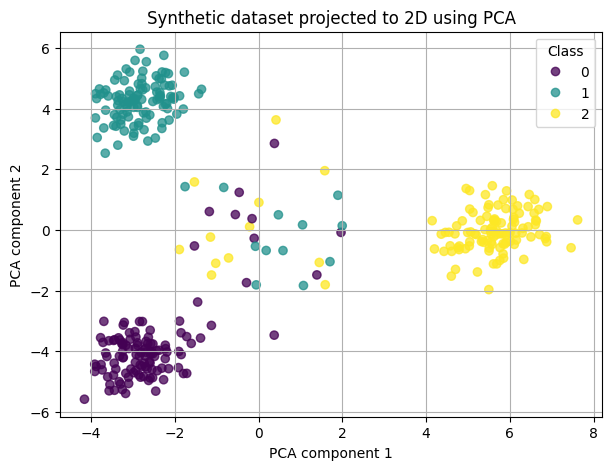

Explained variance ratio: [0.54818902 0.41304609]


In [20]:

X_raw = df[["x1", "x2", "x3", "x4"]].values
y_raw = df["class"].values

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_raw)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_raw, alpha=0.75)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Synthetic dataset projected to 2D using PCA")
plt.legend(*scatter.legend_elements(), title="Class")
plt.grid(True)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)



## 5. Train-test split

We split the data into training and test sets.

The split is stratified, meaning that class proportions are preserved.


In [21]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y_raw,
    test_size=0.25,
    random_state=SEED,
    stratify=y_raw
)

print("Training samples:", X_train_raw.shape[0])
print("Test samples:", X_test_raw.shape[0])


Training samples: 270
Test samples: 90



## 6. Scaling features for quantum angle encoding

The original features are in $[1,10]$.

For angle encoding, it is convenient to map them into $[0,\pi]$:

$$x_j \mapsto \tilde{x}_j \in [0,\pi].$$

Each feature will control one rotation angle.


In [22]:

scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print("Scaled training feature range:")
print("min:", X_train.min(), "max:", X_train.max())


Scaled training feature range:
min: 0.0 max: 3.1415926535897936



## 7. Variational Quantum Classifier design

We use:

- 4 qubits, one for each feature;
- angle encoding with $R_y$ rotations;
- trainable variational layers;
- entangling gates provided by `StronglyEntanglingLayers`;
- 3 expectation values as logits for 3 classes.

The quantum model computes:

$$ f_\theta(x) = \left[\langle Z_0 \rangle,\langle Z_1 \rangle,\langle Z_2 \rangle \right].
$$

These three values are then used as class logits.


In [23]:

n_qubits = 4
n_classes = 3
n_layers = 3

dev = qml.device("default.qubit", wires=n_qubits)

# dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(x, weights):
    # x has shape (4,)
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")

    # Trainable ansatz
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Three outputs for three classes.
    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]


class VQC(nn.Module):
    def __init__(self, n_layers, n_qubits, n_classes):
        super().__init__()

        weight_shape = qml.StronglyEntanglingLayers.shape(
            n_layers=n_layers,
            n_wires=n_qubits
        )

        # Small random initialization helps avoid very unstable initial behavior.
        self.weights = nn.Parameter(0.01 * torch.randn(weight_shape))

        # Trainable affine readout.
        # This gives the quantum logits more flexibility.
        self.scale = nn.Parameter(torch.ones(n_classes))
        self.bias = nn.Parameter(torch.zeros(n_classes))

    def forward(self, x_batch):
        outputs = []

        for x in x_batch:
            q_out = quantum_circuit(x, self.weights)
            q_out = torch.stack(q_out).float()
            outputs.append(q_out)

        outputs = torch.stack(outputs)
        logits = outputs * self.scale + self.bias
        return logits


model = VQC(n_layers=n_layers, n_qubits=n_qubits, n_classes=n_classes)

print(model)
print("Number of trainable parameter tensors:", len(list(model.parameters())))
print("Total trainable scalar parameters:", sum(p.numel() for p in model.parameters()))


VQC()
Number of trainable parameter tensors: 3
Total trainable scalar parameters: 42



## 8. Training configuration

We use cross-entropy loss.

Although the quantum circuit returns expectation values in $[-1,1]$, cross-entropy can still be applied after interpreting the 3 outputs as logits.

For a small laboratory example, we use full-batch training. For larger datasets, mini-batches are preferable.


In [24]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

n_epochs = 80

train_losses = []
train_accuracies = []
test_accuracies = []



## 9. Training loop

At each epoch:

1. compute model outputs on the training set;
2. compute loss;
3. backpropagate gradients;
4. update parameters;
5. compute training and test accuracy.

This can run slower than a classical neural network because each sample passes through a quantum circuit simulation.


In [25]:

for epoch in range(1, n_epochs + 1):
    model.train()

    optimizer.zero_grad()
    logits_train = model(X_train_t)
    loss = criterion(logits_train, y_train_t)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        train_pred = torch.argmax(model(X_train_t), dim=1).numpy()
        test_pred = torch.argmax(model(X_test_t), dim=1).numpy()

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Loss = {loss.item():.4f} | "
            f"Train acc = {train_acc:.3f} | "
            f"Test acc = {test_acc:.3f}"
        )


Epoch 001 | Loss = 1.5745 | Train acc = 0.241 | Test acc = 0.189
Epoch 010 | Loss = 0.9832 | Train acc = 0.530 | Test acc = 0.567
Epoch 020 | Loss = 0.6829 | Train acc = 0.922 | Test acc = 0.911
Epoch 030 | Loss = 0.5733 | Train acc = 0.941 | Test acc = 0.911
Epoch 040 | Loss = 0.4467 | Train acc = 0.933 | Test acc = 0.911
Epoch 050 | Loss = 0.3480 | Train acc = 0.937 | Test acc = 0.922
Epoch 060 | Loss = 0.2794 | Train acc = 0.933 | Test acc = 0.911
Epoch 070 | Loss = 0.2380 | Train acc = 0.937 | Test acc = 0.911
Epoch 080 | Loss = 0.2122 | Train acc = 0.933 | Test acc = 0.922



## 10. Training curves


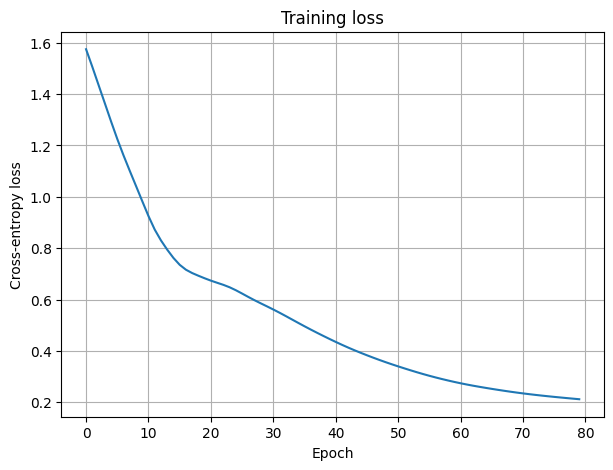

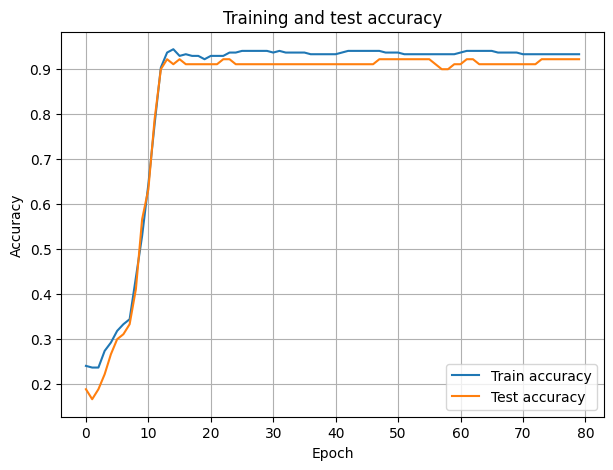

In [26]:

plt.figure(figsize=(7, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(train_accuracies, label="Train accuracy")
plt.plot(test_accuracies, label="Test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and test accuracy")
plt.legend()
plt.grid(True)
plt.show()



## 11. Final evaluation


In [27]:

model.eval()

with torch.no_grad():
    final_logits_test = model(X_test_t)
    final_pred_test = torch.argmax(final_logits_test, dim=1).numpy()

final_accuracy = accuracy_score(y_test, final_pred_test)

print(f"Final test accuracy: {final_accuracy:.4f}")

print("\nClassification report:")
print(classification_report(y_test, final_pred_test, digits=4))


Final test accuracy: 0.9222

Classification report:
              precision    recall  f1-score   support

           0     0.8750    0.9333    0.9032        30
           1     0.9310    0.9000    0.9153        30
           2     0.9655    0.9333    0.9492        30

    accuracy                         0.9222        90
   macro avg     0.9239    0.9222    0.9225        90
weighted avg     0.9239    0.9222    0.9225        90




## 12. Confusion matrix


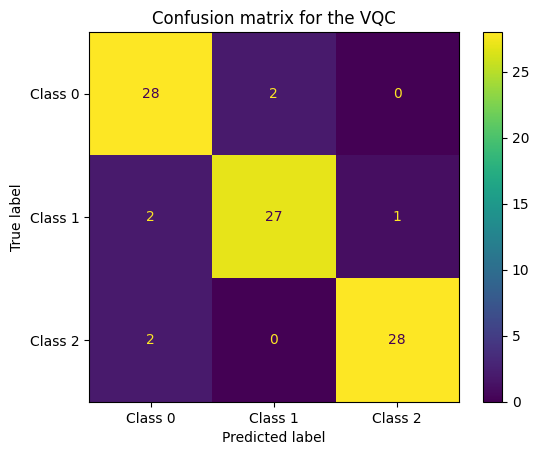

In [28]:

cm = confusion_matrix(y_test, final_pred_test)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f"Class {i}" for i in range(n_classes)]
)

disp.plot()
plt.title("Confusion matrix for the VQC")
plt.show()



## 13. Visualizing predictions in PCA space

Again, PCA is used only for visualization.

The model used all 4 scaled features.


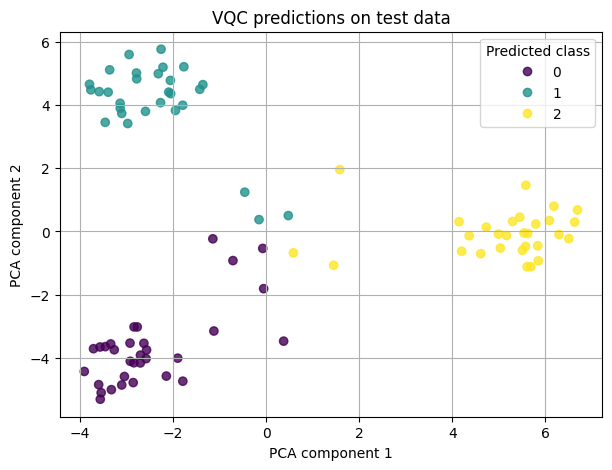

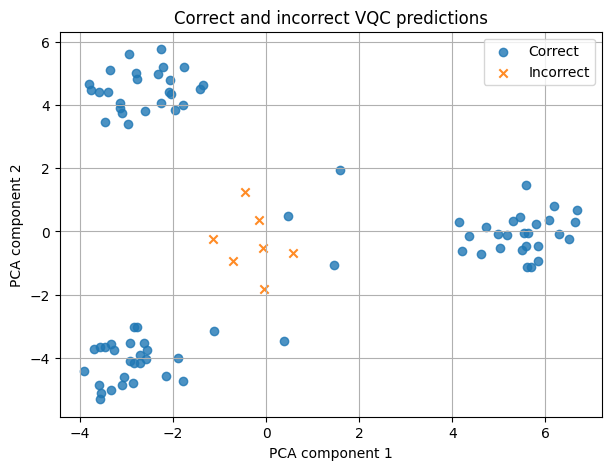

In [29]:

X_test_pca = pca.transform(X_test_raw)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=final_pred_test,
    alpha=0.8
)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("VQC predictions on test data")
plt.legend(*scatter.legend_elements(), title="Predicted class")
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
correct = final_pred_test == y_test
plt.scatter(
    X_test_pca[correct, 0],
    X_test_pca[correct, 1],
    label="Correct",
    alpha=0.8
)
plt.scatter(
    X_test_pca[~correct, 0],
    X_test_pca[~correct, 1],
    label="Incorrect",
    marker="x",
    alpha=0.9
)
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("Correct and incorrect VQC predictions")
plt.legend()
plt.grid(True)
plt.show()



## 14. Inspecting the learned quantum parameters


In [30]:

learned_weights = model.weights.detach().numpy()

print("Quantum weights shape:", learned_weights.shape)
print("First layer parameters:")
print(learned_weights[0])

print("\nReadout scale:", model.scale.detach().numpy())
print("Readout bias:", model.bias.detach().numpy())


Quantum weights shape: (3, 4, 3)
First layer parameters:
[[ 0.09889462 -0.11578181 -0.2643299 ]
 [ 1.3765956  -0.16427243 -0.59495974]
 [ 0.9303904  -0.65962654  0.01459665]
 [ 0.5338072   0.52565235  1.0717624 ]]

Readout scale: [4.1873875  2.8290265  0.96897316]
Readout bias: [-0.03340692  0.00069823 -0.06181846]



## 15. Classical baseline: logistic regression

A VQC result is not meaningful unless compared with a classical baseline.

Since the dataset is deliberately simple and mostly separable, a classical model should perform well. If the VQC does not beat it, this is not a failure of the lab. It is the expected reality for many simple classical datasets.


In [31]:

from sklearn.linear_model import LogisticRegression

baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_train_raw, y_train)

baseline_pred = baseline.predict(X_test_raw)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f"VQC test accuracy: {final_accuracy:.4f}")
print(f"Logistic regression test accuracy: {baseline_acc:.4f}")

print("\nBaseline classification report:")
print(classification_report(y_test, baseline_pred, digits=4))


VQC test accuracy: 0.9222
Logistic regression test accuracy: 0.9000

Baseline classification report:
              precision    recall  f1-score   support

           0     0.8750    0.9333    0.9032        30
           1     0.8710    0.9000    0.8852        30
           2     0.9630    0.8667    0.9123        30

    accuracy                         0.9000        90
   macro avg     0.9030    0.9000    0.9003        90
weighted avg     0.9030    0.9000    0.9003        90




## 16. Discussion questions

1. Did the VQC separate the three classes well?
    - Confusion matrix shows that the examples are truths with very few false positives 
2. Where did the classifier make mistakes?
    - For the outliers
3. Are mistakes concentrated in the deliberately mixed 10% region?
    - More than the others
4. Does the VQC beat the logistic regression baseline?
    - it beats the classical  by .02
5. If not, is this surprising?
    - the backpropagation is the same, classical, difference is the information the algorithm learns with entaglement
6. What happens if you increase `n_layers` from 3 to 5?
    - execution time increases and model starts to overfit
7. What happens if you reduce the dataset separation by increasing the noise?
    - model will not learn as well, and the confusion will increase with more flase positives
8. What happens if the number of shots is finite instead of using exact simulation?
    - More shots => longer runtime; trade-off between precision and time. also slower and unstable training

## 17. Suggested extensions

Try the following modifications:

- replace `StronglyEntanglingLayers` with a custom ansatz;
- use 2, 4, or 6 variational layers;
- add finite shots to the quantum device;
- compare with SVM, random forest, and a small neural network;
- change the mixed fraction from 10% to 20% or 30%;
- remove the affine readout and use raw quantum expectations only.
